# Supervised Learning

## Classification

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
%matplotlib inline


In [2]:
train = pd.read_csv("../data/Iris.csv")
train.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### Exploratory Data Analysis

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [4]:
train['Species'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [5]:
d = train.describe()
d

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


/tmp/ipykernel_29833/637167354.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Species', data=train, palette='RdBu_r')


<Axes: xlabel='Species', ylabel='count'>

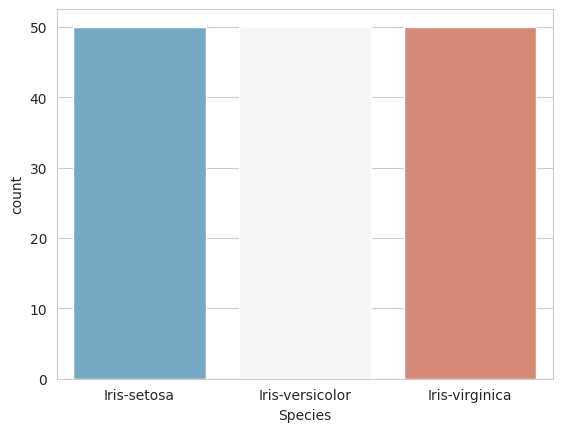

In [6]:
sns.set_style("whitegrid")
sns.countplot(x='Species', data=train, palette='RdBu_r')

/tmp/ipykernel_29833/3068720845.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Species', y='SepalLengthCm', data=train, palette='winter')


<Axes: xlabel='Species', ylabel='SepalLengthCm'>

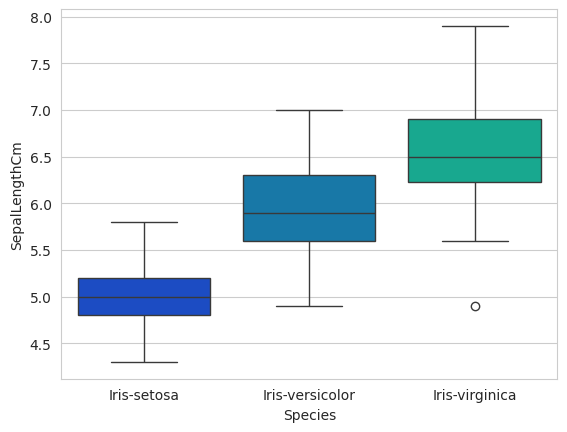

In [7]:
# Species vs SepalLength
sns.set_style('whitegrid')
sns.boxplot(x='Species', y='SepalLengthCm', data=train, palette='winter')

/tmp/ipykernel_29833/1360780543.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Species', y='PetalLengthCm', data=train, palette='winter')


<Axes: xlabel='Species', ylabel='PetalLengthCm'>

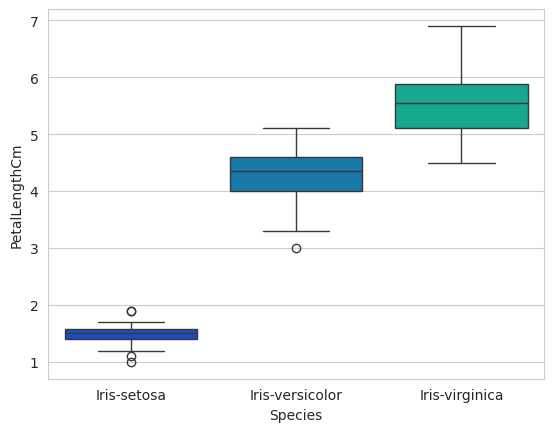

In [8]:
# Species vs PetalLength
sns.set_style('whitegrid')
sns.boxplot(x='Species', y='PetalLengthCm', data=train, palette='winter')

                 PetalLengthCm
Species                       
Iris-setosa              1.464
Iris-versicolor          4.260
Iris-virginica           5.552


(array([0, 1, 2]),
 [Text(0, 0, 'Iris-setosa'),
  Text(1, 0, 'Iris-versicolor'),
  Text(2, 0, 'Iris-virginica')])

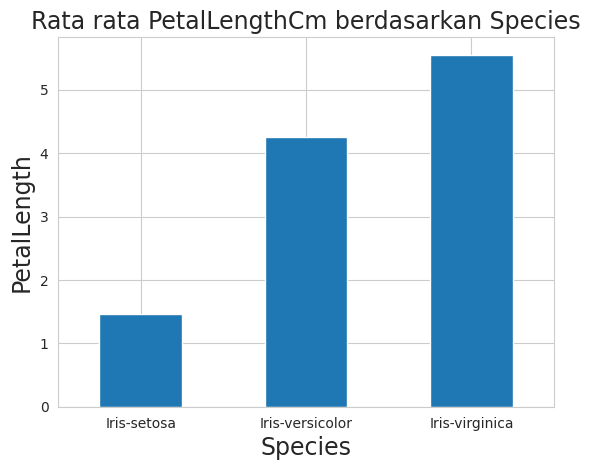

In [9]:
f_class_petalLength = train.groupby('Species')['PetalLengthCm'].mean()
f_class_petalLength = pd.DataFrame(f_class_petalLength)
print(f_class_petalLength)
f_class_petalLength
f_class_petalLength.plot.bar(y='PetalLengthCm', legend=False)
plt.title("Rata rata PetalLengthCm berdasarkan Species", fontsize=17)
plt.xlabel("Species", fontsize=17)
plt.ylabel("PetalLength", fontsize=17)
plt.xticks(rotation=0)

<Axes: title={'center': 'Histogram SepalLength'}, xlabel='Sepal Length', ylabel='Count'>

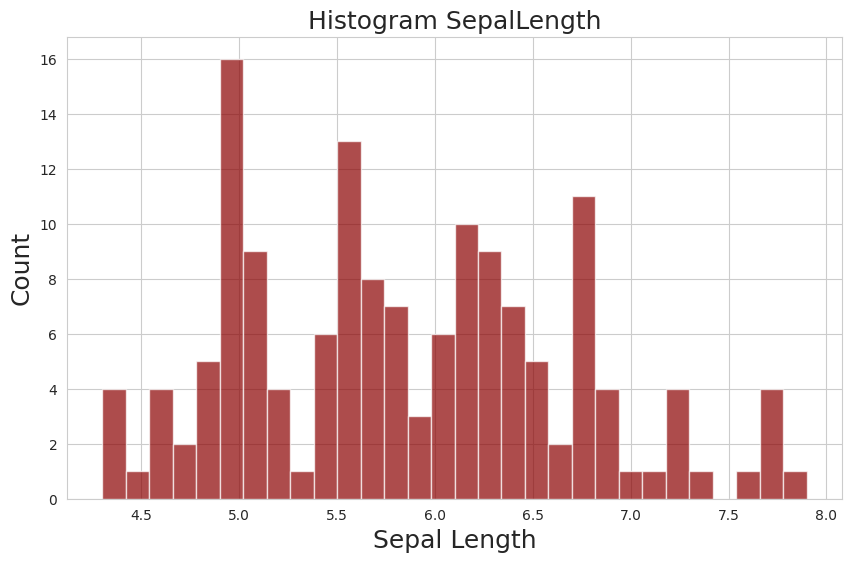

In [10]:
# Cek Distribusi dari petalLength
plt.xlabel("Sepal Length", fontsize=18)
plt.ylabel("Count", fontsize=18)
plt.title("Histogram SepalLength", fontsize=18)
train['SepalLengthCm'].hist(bins=30, color='darkred', alpha=0.7, figsize=(10, 6))

                 SepalLengthCm
Species                       
Iris-setosa              5.006
Iris-versicolor          5.936
Iris-virginica           6.588


(array([0, 1, 2]),
 [Text(0, 0, 'Iris-setosa'),
  Text(1, 0, 'Iris-versicolor'),
  Text(2, 0, 'Iris-virginica')])

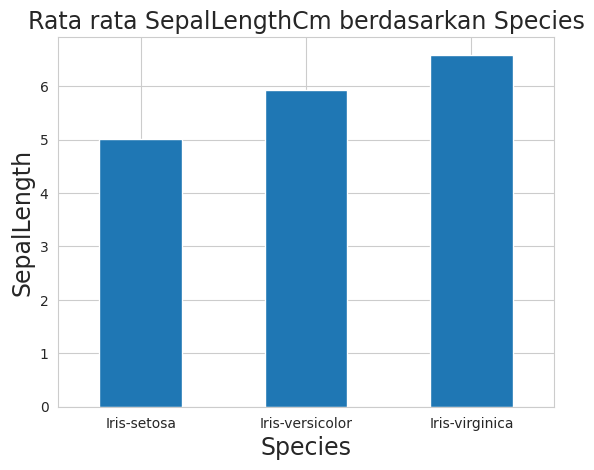

In [11]:
f_class_sepalLength = train.groupby('Species')['SepalLengthCm'].mean()
f_class_sepalLength = pd.DataFrame(f_class_sepalLength)
print(f_class_sepalLength)
f_class_sepalLength
f_class_sepalLength.plot.bar(y='SepalLengthCm', legend=False)
plt.title("Rata rata SepalLengthCm berdasarkan Species", fontsize=17)
plt.xlabel("Species", fontsize=17)
plt.ylabel("SepalLength", fontsize=17)
plt.xticks(rotation=0)

### Fitur Engineering

In [12]:
a = list(f_class_sepalLength['SepalLengthCm'])

def impute_sepal(cols):
    SepalLength = cols['SepalLengthCm']
    Species = cols['Species']
    
    if pd.isnull(SepalLength):
        
        if Species == 'Iris-setosa':
            return a[0]
        elif Species == 'Iris-versicolor':
            return a[1]
        else:
            return a[2]
    
    else:
        return SepalLength

In [13]:
train['SepalLengthCm'] = train[['SepalLengthCm', 'Species']].apply(impute_sepal, axis=1)

Text(0.5, 1.0, 'Bar Plot Jumlah Fitur Numerik Dataset Iris')

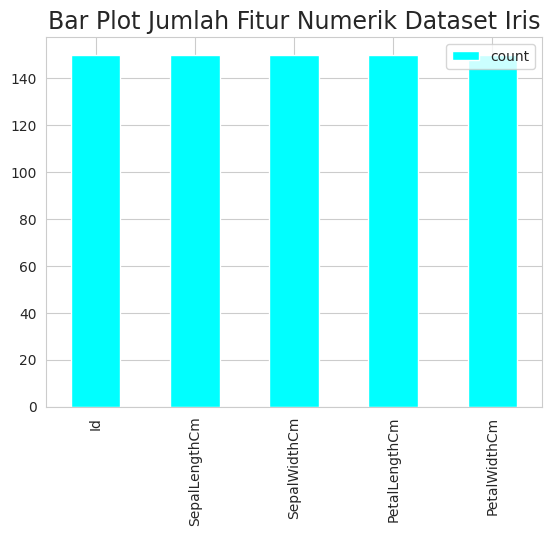

In [14]:
d = train.describe()
dT = d.T
dT.plot.bar(y='count', color='cyan')
plt.title("Bar Plot Jumlah Fitur Numerik Dataset Iris", fontsize=17)

In [15]:
train.drop('Id', axis=1, inplace=True)
train.dropna(inplace=True)
train.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
train['Species'] = le.fit_transform(train['Species'])
train.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Training

In [17]:
X_train, X_test, y_train, y_test = train_test_split(train.drop('Species', axis=1),
                                                    train['Species'], test_size=0.30,
                                                    random_state=42)

In [18]:
print(f'Train shape : {X_train.shape}')
print(f'Test shape : {X_test.shape}')

Train shape : (105, 4)
Test shape : (45, 4)


# **KNN**

In [19]:
clf1 = KNeighborsClassifier()

clf1.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [20]:
y_pred = clf1.predict(X_test)

### Evaluation

In [21]:
accuracy = accuracy_score(y_test, y_pred) # Akurasi model
print(f'Akurasi Model KNN : {accuracy:.2f}')

print("Confusion Matrix : ") #Confusion matrix nya
print(confusion_matrix(y_test, y_pred))

print("classification_report : ")
print(classification_report(y_test, y_pred))

Akurasi Model KNN : 1.00
Confusion Matrix : 
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
classification_report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### jika kita mau mengubah parameter apa saja yang akan kita gunakan maka bisa dilakukan seperti ini

In [22]:
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred1 = clf2.predict(X_test)

In [23]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred1) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred1))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred1))

Akurasi Model KNN: 1.00
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



### jika ingin mencoba semua parameter

In [24]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# 1. Definisikan metrik-metrik scoring yang ingin digunakan
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Buat model KNN
knn = KNeighborsClassifier()

# 4. GridSearch dengan semua metrik, pilih 'f1' sebagai metrik utama (refit)
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Hasil Cross-Validation (Training)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']]
print("\n=== Hasil Evaluasi Training (Cross-Validation) ===")
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

=== Hasil Evaluasi Training (Cross-Validation) ===
                                               params  mean_test_accuracy  \
5   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.952381   
4   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.952381   
1   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.942857   
2   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.942857   
8   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.942857   
3   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.942857   
6   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.942857   
7   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.942857   
10  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.942857   
9   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.942857   
11  {'metric': 'manhattan', 'n_neighbors

In [25]:
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
cv_metrics_sorted.to_excel("hasil_model_KNN.xlsx", index=False)

print("Hasil telah disimpan ke 'hasil_model_KNN.xlsx'")

Hasil telah disimpan ke 'hasil_model_KNN.xlsx'


In [26]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}


In [27]:
y_pred = best_model.predict(X_test)
print("\n=== Evaluasi di Test Set ===")
print(f"Akurasi : {accuracy_score(y_test, y_pred):.2f}")
print(f"Presisi : {precision_score(y_test, y_pred, average='macro'):.2f}")
print(f"Recall : {recall_score(y_test, y_pred, average='macro'):.2f}")
print(f"F1-Score : {f1_score(y_test, y_pred, average='macro'):.2f}")
print("\nClassification Report : ")
print(classification_report(y_test, y_pred))
print("Confusion Matrix : ")
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set ===
Akurasi : 1.00
Presisi : 1.00
Recall : 1.00
F1-Score : 1.00

Classification Report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

Confusion Matrix : 
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [28]:
import numpy as np

# Data Baru (Dalam urutan sama seperti fitur model)
new_data = np.array([[6, 4.8, 3.4, 0.7]])

# Prediksi masuk kedalam species bunga apa
prediction = best_model.predict(new_data)

prediction_label = le.inverse_transform(prediction)

print("Prediksi ini termasuk Species apa", prediction_label[0])

Prediksi ini termasuk Species apa Iris-versicolor


/home/sevti/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(
